In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In this notebook we compare different methods to compute integrals of the form
$$ 
G(x, z, \omega) = \frac{1}{2 \pi} \int_{-\infty}^{+\infty} R(k_x, \omega) \, \frac{e^{i k_z |z|} e^{i k_x x}}{2 \imath k_z} \, dk_x, \quad k_z = \sqrt{k_0^2 - k_x^2}, \; k_0 = \omega / v_p,
$$
where $v_p$ is the P-wave velocity from the top layer containing the source/receiver pairs.
The integral is singular at $k_x = k_0$. We split it in two parts
1. The propagative part: perform the substitution $k_x = k_0 \sin(\theta)$ such as
   $$ 
   G_{\text{prop}}(x, z, \omega) = \frac{1}{2 \pi} \int_{-\pi/2}^{+\pi/2} R(\theta, \omega) \, e^{i k_0 (|z| \cos \theta + x \sin \theta )} d \theta 
   $$
   which is an integral of the form $\int f(\theta) e^{i g(\theta)} d\theta$
2. The evanescent part: perform the substitution $k_x = k_0 \cosh(\psi)$ such as
   $$ 
   G_{\text{ev}}(x, z, \omega) = \frac{1}{2 \pi} \int_{0}^{\psi_{\text{max}}} R(\psi, \omega) \, e^{-k_0 (|z| \sinh \psi + i x \cosh \psi)} d \psi 
   $$
   which is exponentially decaying provided $|z|>0$

We analyze both parts separately, and start with $R(k_x, \omega) = 1$ for which the Green kernel is known explicitly, $G(x, z, \omega) = \frac{i}{4} H_0^{(1)} (kr), \, r=\sqrt{x^2+z^2}$. We look at the performance of Gauss-Legendre, Filon and Levin quadratures.

In [2]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
import time
from src.kernels import green2d


@nb.njit(fastmath=True)
def R(theta):
    return np.ones_like(theta)

The propagative contribution corresponds to the real part of the Hankel Green's function
$$ 1/4 J_0(k_0 r) = \frac{1}{2 \pi} \int_{-\pi/2}^{+\pi/2} e^{i k_0 (|z| \cos \theta + x \sin \theta )} d \theta $$

In [3]:
freqs = np.linspace(0.01, 60.0, 512)
omega = 2.0 * np.pi * freqs
vp, dx, dz = 1500., 1500., 0.
k0 = omega / vp
Green = green2d(omega, vp, dx) 

def max_err(cal, ref):
    num_real = np.abs(np.real(cal) - np.real(ref)) 
    num_im = np.abs(np.real(cal) - np.real(ref))
    den_real, den_im = np.abs(np.real(ref)), np.abs(np.real(ref))
    return np.max(num_real/den_real), np.max(num_im/den_im)

In [31]:
from src.quadrature.gauss_leg import get_weights
from src.quadrature.integrands import integrand_prop

G_gauss = np.zeros(len(omega), dtype=complex)
nq = 200 # number of quadrature points
# generate weights
weights, theta_q, scale = get_weights(-np.pi/2., np.pi/2., nq)
print(weights.shape)
start = time.time()
integrand = integrand_prop(theta_q[:, None], k0[None, :], dz, dx, R)
G_gauss = scale * np.dot(weights[None, :], integrand)
end = time.time()
print(integrand.shape)
print(f"quadrature elapsed: {end-start:.2f} s")
print("number of calls = ", nq)
G_gauss *= 1./(4.*np.pi*1j)

print("max error levin", max_err(np.imag(G_gauss), np.imag(Green)))

(200,)
(200, 512)
quadrature elapsed: 0.01 s
number of calls =  200
max error levin (np.float64(162.67999970138865), np.float64(162.67999970138865))


In [60]:
from src.quadrature.levin import get_weights_levin_numba
Nl = 30
thetas = np.linspace(-np.pi/2, np.pi/2, Nl+1)
k0_vec = omega / vp
print(k0_vec.shape)
G_levin = np.zeros(len(omega), dtype=complex)

start = time.time()
weights_levin = get_weights_levin_numba(k0_vec, dz, dx, thetas, N=12)
end = time.time()
print(weights_levin.shape)
R_vals = np.ones(len(omega), dtype=complex)
print(R_vals.shape)
# Quadrature result
Glevin = np.dot(weights_levin, R_vals)

Glevin = np.zeros(len(omega), dtype=complex)
# Multiply normalization
Glevin = weights_levin / (4*np.pi*1j)
#G_levin *= 1./(4*np.pi*1j)

print(f"Elapsed: {end-start:.3f} s")
print("max error levin", max_err(np.imag(Glevin), np.imag(Green)))

(512,)
(512,)
(512,)
Elapsed: 0.009 s
max error levin (np.float64(0.0004852280591985783), np.float64(0.0004852280591985783))


In [ ]:
'''
start = time.time()
G_filon = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega[w] / vp
    G_filon[w] = composite_filon(-np.pi/2., np.pi/2., Nsub, k0, dz, dx, reflectivity, 'cubic')
end = time.time()
print(f"quadrature elapsed: {end-start:.2f} s")
print("number of calls = ", 3.*Nsub)
G_filon *= 1./(4.*np.pi*1j)'''


'\nstart = time.time()\nG_filon = np.zeros(len(omega), dtype=complex)\nfor w in range(len(omega)):\n    k0 = omega[w] / vp\n    G_filon[w] = composite_filon(-np.pi/2., np.pi/2., Nsub, k0, dz, dx, reflectivity, \'cubic\')\nend = time.time()\nprint(f"quadrature elapsed: {end-start:.2f} s")\nprint("number of calls = ", 3.*Nsub)\nG_filon *= 1./(4.*np.pi*1j)'

(0.06283185307179587, 376.99111843077515)

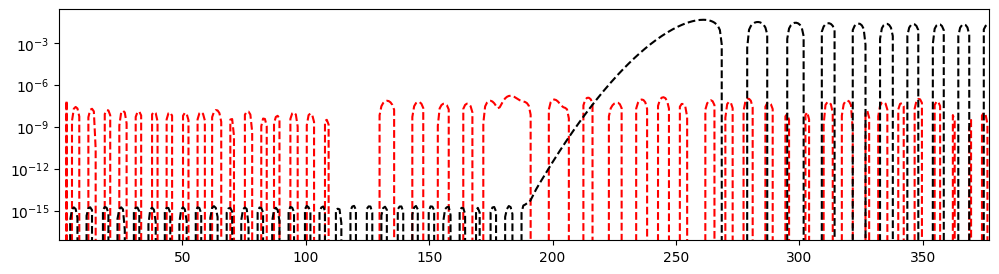

In [61]:
plt.figure(figsize=(12,3))
#plt.plot(omega, error_filon, "r--")
#plt.plot(omega, error_levin, "b--")
#plt.plot(omega, error_gauss, "g--")
#plt.plot(omega, np.imag(G_filon), "r--")
plt.plot(omega, np.imag(Glevin-Green.flatten()), "r--")
plt.plot(omega, np.imag(G_gauss.flatten()-Green.flatten()), "k--")
plt.yscale('log')
plt.xlim([np.min(omega),np.max(omega)])

In [ ]:
# we suppose kx > (omega/vp)
def integrand_evan(kx, k0, z_abs, x, R_func):
    R_val = R_func(kx)
    gamma = np.sqrt(kx**2 - k0**2)
    return R_val * np.exp(1j * kx * x) * np.exp(-gamma*z_abs) / gamma

def integrand_evan_cosh(psi, k0, z_abs, x, R_func):
    kx = k0 * np.cosh(psi)
    R_val = R_func(kx)
    phase = z_abs *np.sinh(psi) - 1j * x *np.cosh(psi)
    return R_val * np.exp(-k0*phase)

In [ ]:
#freqs_ev = np.linspace(0.01, 40.0, 1024)
omega_ev = 2.0 * np.pi * freqs #+ 2.0*1j
Ng = 400
factor = 2.
start = time.time()
G_gauss_evan = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega_ev[w] / vp
    kmax = factor*k0
    G_gauss_evan[w] = gauss_legendre_quad(k0, kmax, Ng, k0, dz, dx, unit, integrand=integrand_evan)
end = time.time()
print(f"quadrature elapsed: {end-start:.2f} s")
print("number of calls = ", Ng)
G_gauss_evan *= -1./(2.*np.pi)

start = time.time()
G_ch_evan = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega_ev[w] / vp
    kmax = factor*k0
    psi_max = np.arccosh(kmax/k0)
    G_ch_evan[w] = gauss_legendre_quad(0., psi_max, Ng, k0, dz, dx, unit, integrand=integrand_evan_cosh)
end = time.time()
print(f"quadrature elapsed: {end-start:.2f} s")
print("number of calls = ", Ng)
G_ch_evan *= -1./(2.*np.pi)

NameError: name 'gauss_legendre_quad' is not defined

In [ ]:
Green = green2d(omega_ev, vp, dx) 
Green = Green.flatten()

In [ ]:
from scipy.integrate import quad
G_scipy = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega_ev[w] / vp
    kmax = factor*k0
    result, error = quad(integrand_evan, k0, kmax, args=(k0, dz, dx, unit), points=[k0], limit=300)
    G_scipy[w] = result * (-1./(2.*np.pi))

/home/marchnep/.local/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:619: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagpe(func, a, b, the_points, args, full_output,
/tmp/ipykernel_30634/288921928.py:6: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result, error = quad(integrand_evan, k0, kmax, args=(k0, dz, dx, unit), points=[k0], limit=300)
/tmp/ipykernel_30634/3568429688.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return R_val * np.exp(1j * kx * x) * np.exp(-gamma*z_abs) / gamma


In [ ]:
error_gauss = np.abs(np.real(Green) - np.real(G_gauss_evan)) / np.abs(np.real(Green))
print("max err gauss", np.max(error_gauss))
error_ch = np.abs(np.real(Green) - np.real(G_ch_evan)) / np.abs(np.real(Green))
print("max err ch", np.max(error_ch))
error_scipy = np.abs(np.real(Green) - np.real(G_scipy)) / np.abs(np.real(Green))
print("max err scipy", np.max(error_scipy))

max err gauss 649.2705880856048
max err ch 640.6897354531719
max err scipy inf


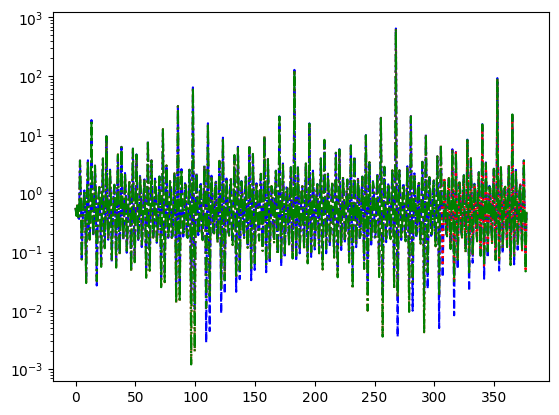

In [ ]:
plt.plot(np.real(omega_ev), error_gauss, 'b--')
plt.plot(np.real(omega_ev), error_ch, 'r:')
plt.plot(np.real(omega_ev), error_scipy, 'g-.')
plt.yscale('log')

(-0.1, 0.1)

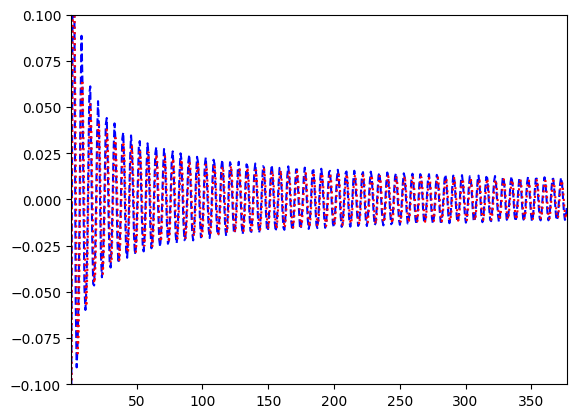

In [ ]:
plt.plot(np.real(omega_ev), np.real(G_ch_evan), 'b--')
plt.plot(np.real(omega_ev), np.real(Green), 'r:')
plt.xlim([np.min(omega_ev),np.max(omega_ev)])
plt.ylim([-0.1,0.1])